# Detection of vehicles

The detection & tracking of cars via security cameras can be challenging due to environmental conditions. Here we will specifically focus on the detection robustness under different lightning conditions: daylight, night, shadow, urban or highway illumination by street lantarns and advertising.

For example look at the two following images taken from the same camera, the first is during the day and the second taken during the night:

In [31]:
from pathlib import Path
from PIL import Image
import cv2
from IPython.display import display
from ultralytics.utils.plotting import Annotator
from enum import Enum
import numpy as np


# Classes
names = {
    0: "pedestrian",
    1: "people",
    2: "bicycle",
    3: "car",
    4: "van",
    5: "truck",
    6: "tricycle",
    7: "awning-tricycle",
    8: "bus",
    9: "motor",
}

class Label:
    def __init__(self, annotation):
        self.pos = annotation[1:]
        self.cls = annotation[0]


def read_labels(label_path):
    with open(label_path, encoding="utf-8") as file:
        labels = []
        for row in [x.split(" ") for x in file.read().strip().splitlines()]:
            print(row)
            # All position values are normalized
            cls, x_center, y_center, w_norm, h_norm = map(float, row[:])
            labels.append(Label([cls, x_center, y_center, w_norm, h_norm]))
    return labels

def show_cv2_img(img):
    im = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Converting BGR to RGB
    display(Image.fromarray(im))


def show_labeled_img(img_path, label_path=None, label_text=False):
    img = cv2.imread(img_path)
    if not label_path is None:
        labels = read_labels(label_path)
        annotator = Annotator(img, line_width=3)
        label = labels[0]
        pos = np.array([img.shape[1], img.shape[0], img.shape[1], img.shape[0]]) * np.array(label.pos)
        #x, y, w, h = pos
        #y, x, h, w = x, y, w, h
        #pos = [y, x, h, w]
        annotator.box_label(pos, names[label.cls], (255, 0, 0))
    im = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(im))



['3', '0.372500', '0.546320', '0.109286', '0.105330']
['8', '0.114286', '0.500000', '0.165714', '0.144670']
['3', '0.295357', '0.472716', '0.106429', '0.087563']
['5', '0.626071', '0.462563', '0.187857', '0.166244']
['3', '0.701071', '0.576142', '0.092143', '0.091371']
['8', '0.545357', '0.359772', '0.255000', '0.232234']
['3', '0.931786', '0.024746', '0.055000', '0.049492']


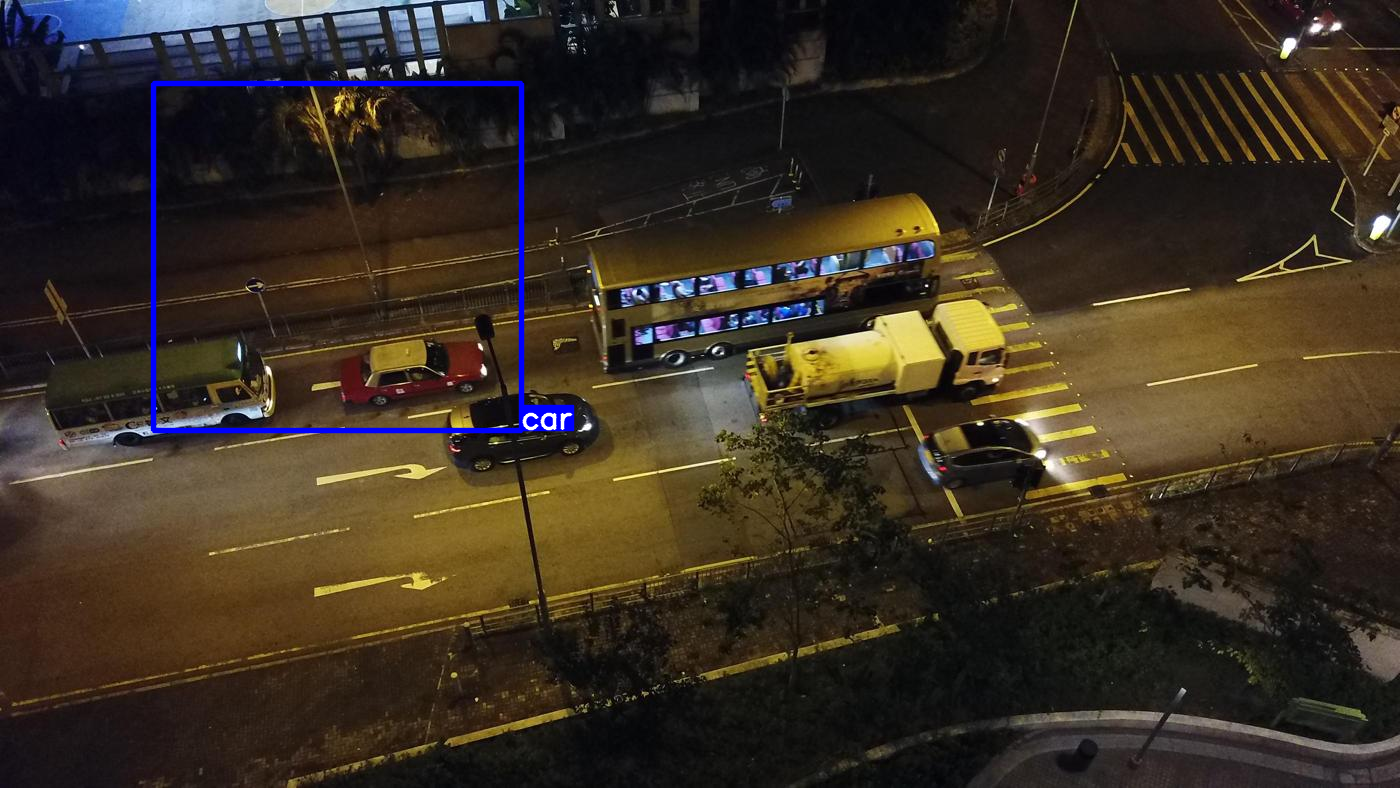

In [32]:
# example light vs dark images
base_folder = Path("C:/Users/micha/OneDrive/Desktop/aiplab-projects/datasets/visdrone")
image_folder = base_folder / "images"
label_folder = base_folder / "labels"
# Day-light
img_id = "9999953_00000_d_0000159"
img_path = (image_folder / "train" / f"{img_id}.jpg").as_posix()
label_path = (label_folder / "train" / f"{img_id}.txt").as_posix()
img = cv2.imread(img_path)
#show_cv2_img(img)
show_labeled_img(img_path, label_path)
# Night
#img_path = (image_folder / "train" / "9999953_00000_d_0000159.jpg").as_posix()
#img = cv2.imread(img_path)
#show_cv2_img(img)


## Data description

## Detection via YOLO26

### Training network

### Visualization result examples

## Detection Analysis

In [1]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo26n.pt")  # load a pretrained model (recommended for training)

# Train the model
results = model.train(data="coco8.yaml", epochs=100, imgsz=640)

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\micha\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41  Python-3.12.0 torch-2.11.0+cpu CPU (Intel Core i7-6700HQ 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, i

In [2]:
from ultralytics import YOLO

# Load a pretrained YOLO26 nano model
model = YOLO("yolo26n.pt")


# Load a model
model = YOLO("yolo26n.yaml")  # build a new model from YAML
model = YOLO("yolo26n.pt")  # load a pretrained model (recommended for training)
model = YOLO("yolo26n.yaml").load("yolo26n.pt")  # build from YAML and transfer weights

# Train the model
results = model.train(data="coco8.yaml", epochs=100, imgsz=640)


Transferred 708/708 items from pretrained weights
Ultralytics 8.4.41  Python-3.12.0 torch-2.11.0+cpu CPU (Intel Core i7-6700HQ 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=

In [ ]:
# Run inference on an image
#results = model("image.jpg")

FileNotFoundError: image.jpg does not exist